In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random
import sys

sys.path.append(str(Path.cwd().parent))

from ultralytics import YOLO


In [8]:

PROJECT_ROOT = Path("..")
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "detection" / "bccd"
BEST_MODEL = PROJECT_ROOT / "outputs" / "checkpoints" / "detection_best.pt"


if not BEST_MODEL.exists():
    BEST_MODEL = PROJECT_ROOT / "runs" / "detect" / "blood_detection" / "detection_run" / "weights" / "best.pt"


model = YOLO(str(BEST_MODEL))


val_txt = DATA_ROOT / "splits" / "val.txt"
with open(val_txt, 'r') as f:
    val_images = [Path(line.strip()) for line in f.readlines()]


sample_images = random.sample(val_images, min(4, len(val_images)))


CLASS_NAMES = ['WBC', 'RBC', 'Platelets']
COLORS = [(0, 255, 0), (255, 0, 0), (255, 255, 0)]  

plt.figure(figsize=(16, 12))



<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>


image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00337.jpg: 480x640 1 WBC, 28 RBCs, 701.4ms
Speed: 98.7ms preprocess, 701.4ms inference, 53.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00031.jpg: 480x640 2 WBCs, 19 RBCs, 2 Plateletss, 208.0ms
Speed: 4.1ms preprocess, 208.0ms inference, 5.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00251.jpg: 480x640 1 WBC, 12 RBCs, 1 Platelets, 686.9ms
Speed: 4.6ms preprocess, 686.9ms inference, 12.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00014.jpg: 480x640 1 WBC, 20 RBCs, 4 Plateletss, 895.4ms
Speed: 13.4ms preprocess, 895.4ms inference, 10.0ms postprocess per image at shape (1, 3, 480, 640)


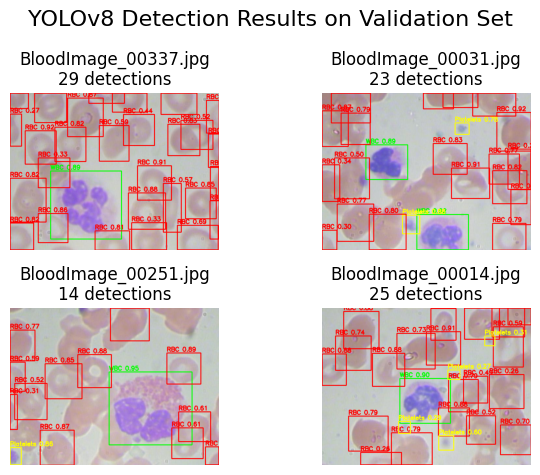

[INFO] Best model loaded from: ..\runs\detect\blood_detection\detection_run\weights\best.pt
[INFO] Total validation images: 73


In [9]:
for i, img_path in enumerate(sample_images):
    
    results = model(img_path, conf=0.25)
    
    
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    
    boxes = results[0].boxes
    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = box.conf[0].item()
            cls_id = int(box.cls[0].item())
            
            color = COLORS[cls_id % len(COLORS)]
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = f"{CLASS_NAMES[cls_id]} {conf:.2f}"
            cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"{img_path.name}\n{len(boxes) if boxes is not None else 0} detections")
    plt.axis('off')

plt.suptitle("YOLOv8 Detection Results on Validation Set", fontsize=16)
plt.tight_layout()
plt.show()


print(f"[INFO] Best model loaded from: {BEST_MODEL}")
print(f"[INFO] Total validation images: {len(val_images)}")

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random
import sys


sys.path.append(str(Path.cwd().parent))

from ultralytics import YOLO
from src.data.preprocessing import load_yolo_labels


PROJECT_ROOT = Path("..")
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "detection" / "bccd"
BEST_MODEL = PROJECT_ROOT / "outputs" / "checkpoints" / "detection_best.pt"


if not BEST_MODEL.exists():
    BEST_MODEL = PROJECT_ROOT / "runs" / "detect" / "blood_detection" / "detection_run" / "weights" / "best.pt"


model = YOLO(str(BEST_MODEL))


val_txt = DATA_ROOT / "splits" / "val.txt"
with open(val_txt, 'r') as f:
    val_images = [Path(line.strip()) for line in f.readlines()]


sample_images = random.sample(val_images, min(4, len(val_images)))


CLASS_NAMES = ['WBC', 'RBC', 'Platelets']
PRED_COLORS = {
    0: (0, 255, 0),     
    1: (255, 0, 0),     
    2: (255, 255, 0)    
}
GT_COLOR = (255, 255, 255)  
GT_COLOR_BGR = (255, 255, 0) 


image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00407.jpg: 480x640 1 WBC, 12 RBCs, 3 Plateletss, 195.5ms
Speed: 4.7ms preprocess, 195.5ms inference, 2.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00224.jpg: 480x640 1 WBC, 8 RBCs, 1 Platelets, 605.4ms
Speed: 4.2ms preprocess, 605.4ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00332.jpg: 480x640 1 WBC, 21 RBCs, 941.3ms
Speed: 7.8ms preprocess, 941.3ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00349.jpg: 480x640 1 WBC, 20 RBCs, 334.5ms
Speed: 5.6ms preprocess, 334.5ms inference, 4.1ms postprocess per image at shape (1, 3, 480, 640)


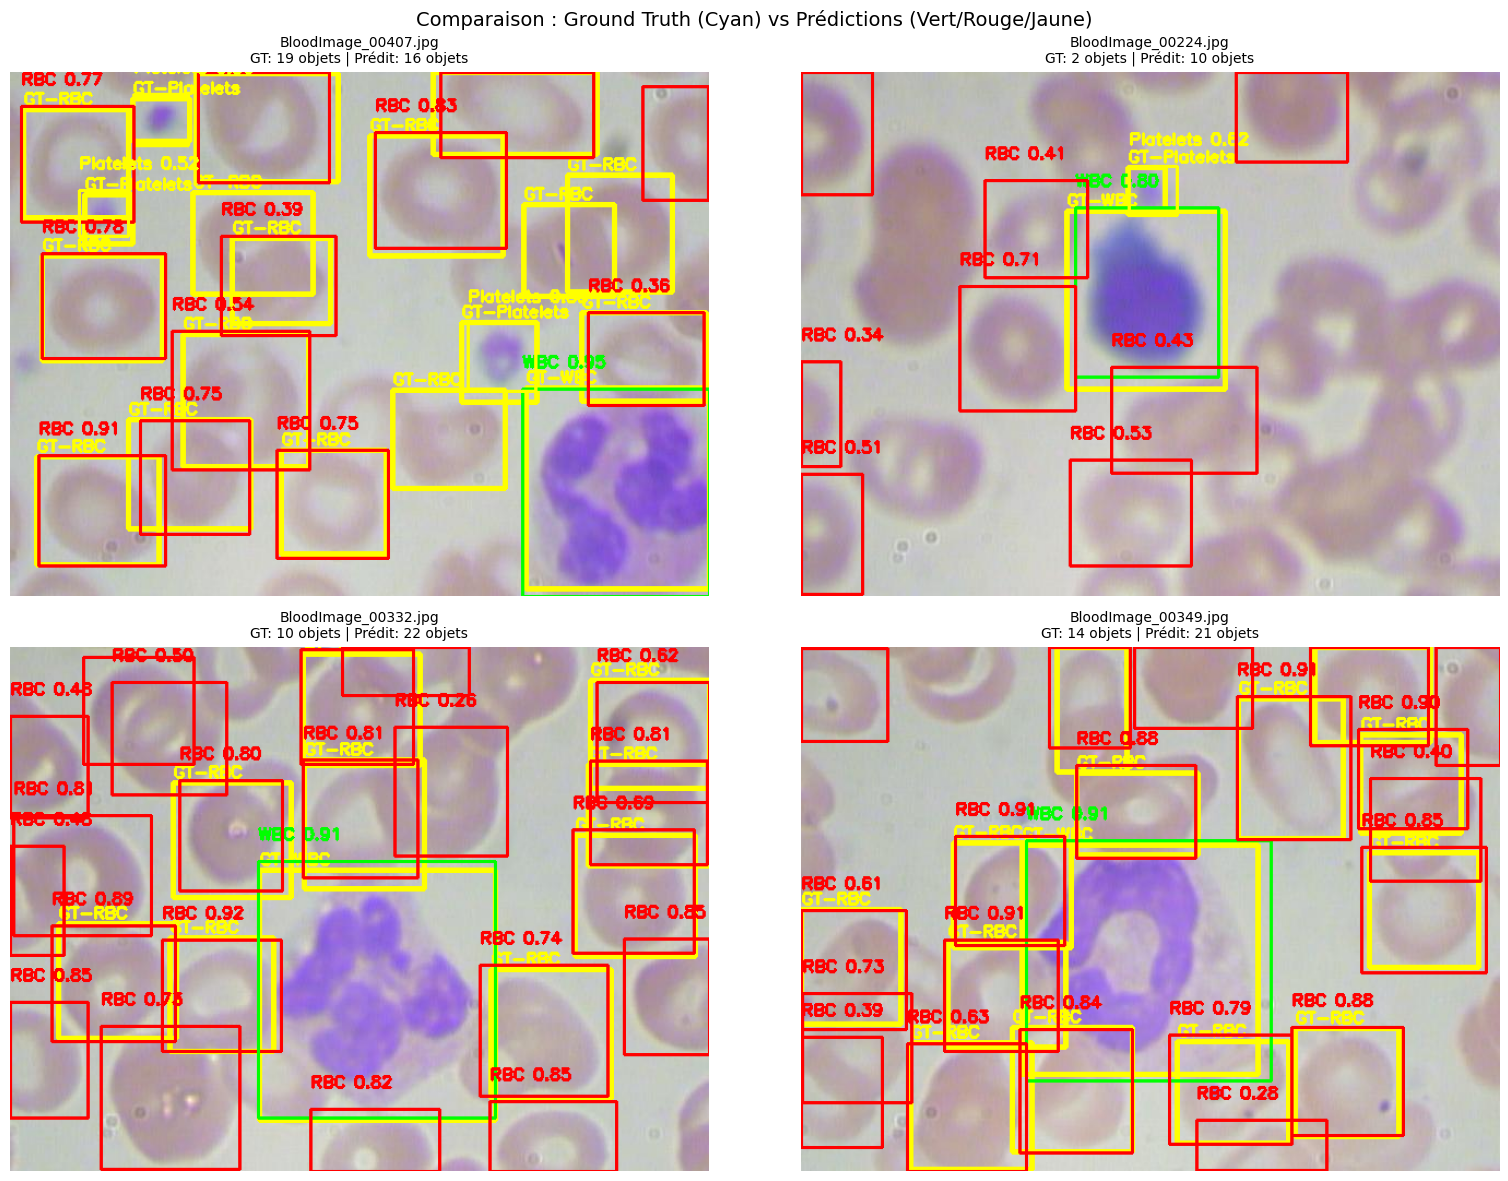

In [11]:

plt.figure(figsize=(16, 12))

for i, img_path in enumerate(sample_images):
    
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"[WARNING] Impossible de charger {img_path}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    
    label_path = DATA_ROOT / "labels" / f"{img_path.stem}.txt"
    gt_boxes = load_yolo_labels(label_path, w, h)
    gt_count = len(gt_boxes)
    
    
    for class_id, (xmin, ymin, xmax, ymax) in gt_boxes:
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), GT_COLOR_BGR, 3)  
        cv2.putText(img, f"GT-{CLASS_NAMES[class_id]}", (xmin, ymin - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, GT_COLOR_BGR, 2)
    
    
    results = model(img_path, conf=0.25)
    boxes = results[0].boxes
    pred_count = len(boxes) if boxes is not None else 0
    
    
    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = box.conf[0].item()
            cls_id = int(box.cls[0].item())
            
            color = PRED_COLORS.get(cls_id, (255, 255, 255))
            
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            label = f"{CLASS_NAMES[cls_id]} {conf:.2f}"
            cv2.putText(img, label, (x1, y1 - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"{img_path.name}\nGT: {gt_count} objets | Prédit: {pred_count} objets", fontsize=10)
    plt.axis('off')

plt.suptitle("Comparaison : Ground Truth (Cyan) vs Prédictions (Vert/Rouge/Jaune)", fontsize=14)
plt.tight_layout()
plt.show()


image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00407.jpg: 480x640 1 WBC, 12 RBCs, 3 Plateletss, 206.8ms
Speed: 4.3ms preprocess, 206.8ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00224.jpg: 480x640 1 WBC, 8 RBCs, 1 Platelets, 253.1ms
Speed: 5.8ms preprocess, 253.1ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00332.jpg: 480x640 1 WBC, 21 RBCs, 370.0ms
Speed: 5.6ms preprocess, 370.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 C:\Users\HP\Desktop\blood\data\raw\detection\bccd\images\BloodImage_00349.jpg: 480x640 1 WBC, 20 RBCs, 236.9ms
Speed: 4.8ms preprocess, 236.9ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


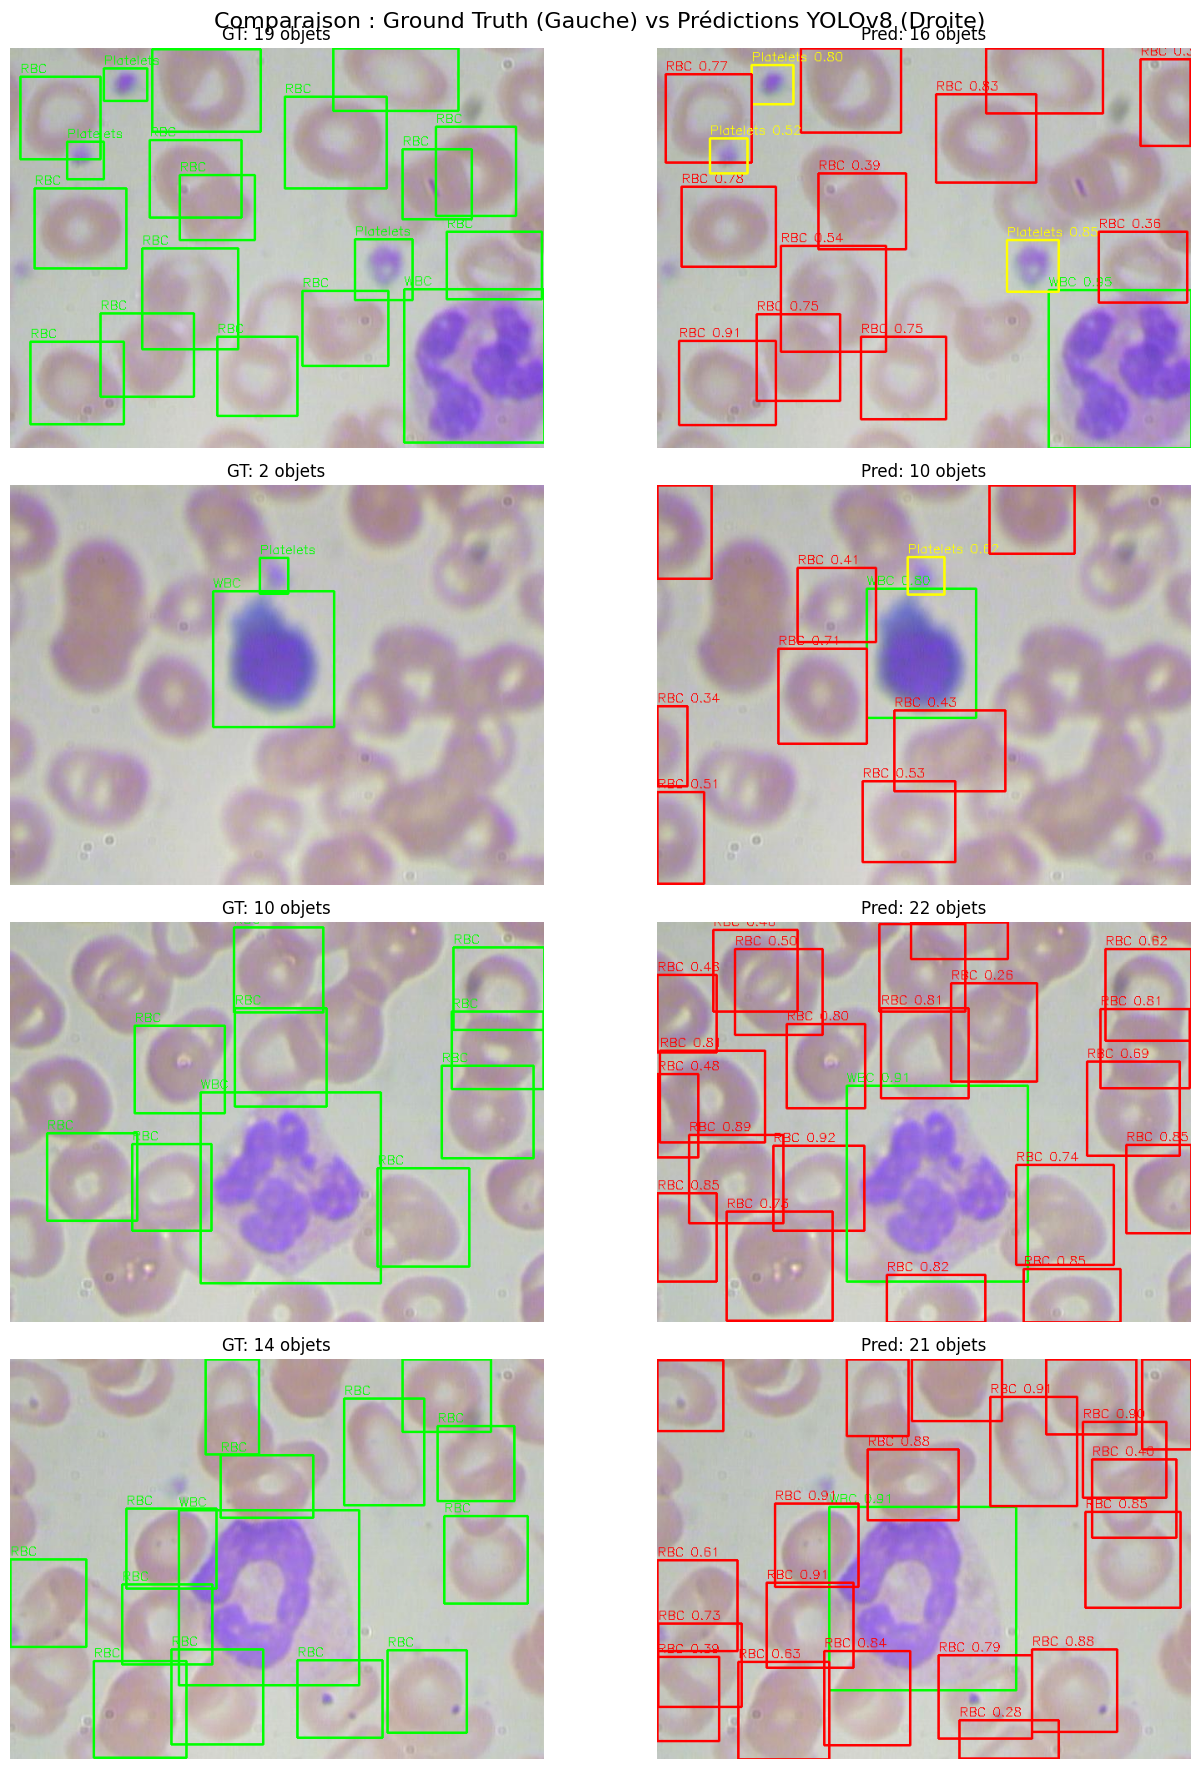

In [12]:

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for i, img_path in enumerate(sample_images):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape
    
    
    gt_img = img_rgb.copy()
    label_path = DATA_ROOT / "labels" / f"{img_path.stem}.txt"
    gt_boxes = load_yolo_labels(label_path, w, h)
    for class_id, (xmin, ymin, xmax, ymax) in gt_boxes:
        cv2.rectangle(gt_img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)  
        cv2.putText(gt_img, CLASS_NAMES[class_id], (xmin, ymin-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    
    axes[i, 0].imshow(gt_img)
    axes[i, 0].set_title(f"GT: {len(gt_boxes)} objets")
    axes[i, 0].axis('off')
    
    
    pred_img = img_rgb.copy()
    results = model(img_path, conf=0.25)
    boxes = results[0].boxes
    if boxes is not None:
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            conf = box.conf[0].item()
            cls_id = int(box.cls[0].item())
            color = PRED_COLORS.get(cls_id, (255, 255, 255))
            cv2.rectangle(pred_img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(pred_img, f"{CLASS_NAMES[cls_id]} {conf:.2f}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    
    axes[i, 1].imshow(pred_img)
    axes[i, 1].set_title(f"Pred: {len(boxes) if boxes else 0} objets")
    axes[i, 1].axis('off')

plt.suptitle("Comparaison : Ground Truth (Gauche) vs Prédictions YOLOv8 (Droite)", fontsize=16)
plt.tight_layout()
plt.show()